## The Impact of SEPTA Bus Service Cuts on Travel Time and Commuting Equity in Philadelphia

### Part I. Background

1. Background

SEPTA has faced long-standing financial constraints that have intensified in recent years, particularly following the significant ridership decline during and after the COVID-19 pandemic. These budget pressures have left the agency unable to sustain its full level of bus operations, forcing consideration of substantial service reductions across the network. Because bus transit plays a critical role in supporting mobility for residents who rely on public transportation for work, education, and essential services, understanding the broader implications of these cuts is especially important. The financial context under which SEPTA is operating forms the foundation of this project and motivates a deeper examination of how reduced service levels may reshape accessibility and equity across Philadelphia.

2. Research Purpose

The primary goal of this project is to evaluate how SEPTA’s proposed bus service reductions influence access to transit and the potential mobility of Philadelphia residents. By analyzing changes in service levels and accessibility, we aim to understand the implications of reduced bus frequency on both the spatial distribution of service and the populations most dependent on it. Ultimately, our purpose is to assess whether the proposed cuts disproportionately affect certain neighborhoods or demographic groups and to explore how these changes may alter the broader landscape of commuting opportunities. This analysis seeks to provide a data-driven perspective on how transit service restructuring can shape equity outcomes in urban mobility systems.

3. Research Questions and Analytical Adjustment

This project was originally guided by several central research questions, including how service frequency changes before and after the proposed cuts, which neighborhoods experience the greatest reductions in bus availability, and how travel times may shift under a reduced-service network. We initially planned to evaluate changes in network-based travel times using a routing model; however, persistent technical errors prevented this analysis from being completed reliably. The routing package repeatedly returned incorrect “outside of service area” errors for many origin–destination pairs, making the results unsuitable for comparison. As a result, the final phase of the project shifts toward examining changes in accessibility rather than travel times. While this adjusted approach still employs network analysis, it carries notable limitations and should be interpreted with caution. Nevertheless, it allows us to explore the spatial and demographic patterns of service reductions within the constraints of the available tools.

4. Data Sources

This study integrates multiple datasets that together enable a comprehensive assessment of service cuts and their potential impacts. Operational data were derived from SEPTA’s GTFS feed, which provides detailed information on routes, trips, and scheduled service levels before and after the reductions. Demographic characteristics were obtained through the U.S. Census Bureau’s ACS API, allowing us to evaluate how service changes align with variables such as income, race, and household composition. Additionally, the street network used in our accessibility analysis was constructed using OpenStreetMap (OSM) data, which supports the modeling of spatial connectivity and walkability across Philadelphia. These combined data sources make it possible to assess the intersection of transit service, population characteristics, and network accessibility in a cohesive framework.

### Part II. Distribution characteristics of service reductions and basic demographic factors

In [1]:
import pandas as pd
import geopandas as gpd
import re
import matplotlib.pyplot as plt
import seaborn as sns

#### Comparison of GTF data before and after reduction

In [ ]:
trip_after=pd.read_csv("../Python_FinalProject/Dataset/gtfs_public_after/google_bus_after/trips.txt")
routes_after=pd.read_csv("../Python_FinalProject/Dataset/gtfs_public_after/google_bus_after/routes.txt")
stops_after=pd.read_csv("../Python_FinalProject/Dataset/gtfs_public_after/google_bus_after/stops.txt")
shapes_after=pd.read_csv("../Python_FinalProject/Dataset/gtfs_public_after/google_bus_after/shapes.txt")
stop_times_after=pd.read_csv("../Python_FinalProject/Dataset/gtfs_public_after/google_bus_after/stop_times.txt")

In [3]:
trip_after.head()

,route_id,service_id,trip_id,trip_headsign,trip_short_name,direction_id,block_id,shape_id,wheelchair_accessible,bikes_allowed
0,LUCYGO,22,375710,Gold Loop,NaN,0,8502,304916,1,NaN
1,LUCYGO,22,375751,Gold Loop,NaN,0,8504,304918,1,NaN
2,LUCYGO,22,375741,Gold Loop,NaN,0,8505,304918,1,NaN
3,LUCYGO,22,375736,Gold Loop,NaN,0,8507,304918,1,NaN
4,LUCYGO,22,375747,Gold Loop,NaN,0,8508,304918,1,NaN


In [ ]:
trip_before=pd.read_csv("../Python_FinalProject/Dataset/gtfs_public_before/google_bus/trips.txt")
routes_before=pd.read_csv("../Python_FinalProject/Dataset/gtfs_public_before/google_bus/routes.txt")
stops_before=pd.read_csv("../Python_FinalProject/Dataset/gtfs_public_before/google_bus/stops.txt")
shapes_before=pd.read_csv("../Python_FinalProject/Dataset/gtfs_public_before/google_bus/shapes.txt")
stop_times_before=pd.read_csv("../Python_FinalProject/Dataset/gtfs_public_before/google_bus/stop_times.txt")

Top 10 & Bottom 10 Bus Trips per Route:

In [87]:
bus_routes = routes_before[routes_before["route_type"] == 3]["route_id"]

trip_bus_before = trip_before[trip_before["route_id"].isin(bus_routes)]

trips_per_route = trip_bus_before.groupby("route_id").size()

top10_trips = trips_per_route.sort_values(ascending=False).head(10)
bottom10_trips = trips_per_route.sort_values(ascending=True).head(10)

print("Bus Trips per Route — Top 10:")
print(top10_trips)

print("Bus Trips per Route — Bottom 10:")
print(bottom10_trips)

Bus Trips per Route — Top 10:
route_id
52    598
23    523
42    504
33    504
47    492
45    478
17    467
21    458
18    453
63    448
dtype: int64
Bus Trips per Route — Bottom 10:
route_id
78         2
80         7
62         8
MANNLP    10
133       13
206       15
120       18
150       19
201       32
128       37
dtype: int64


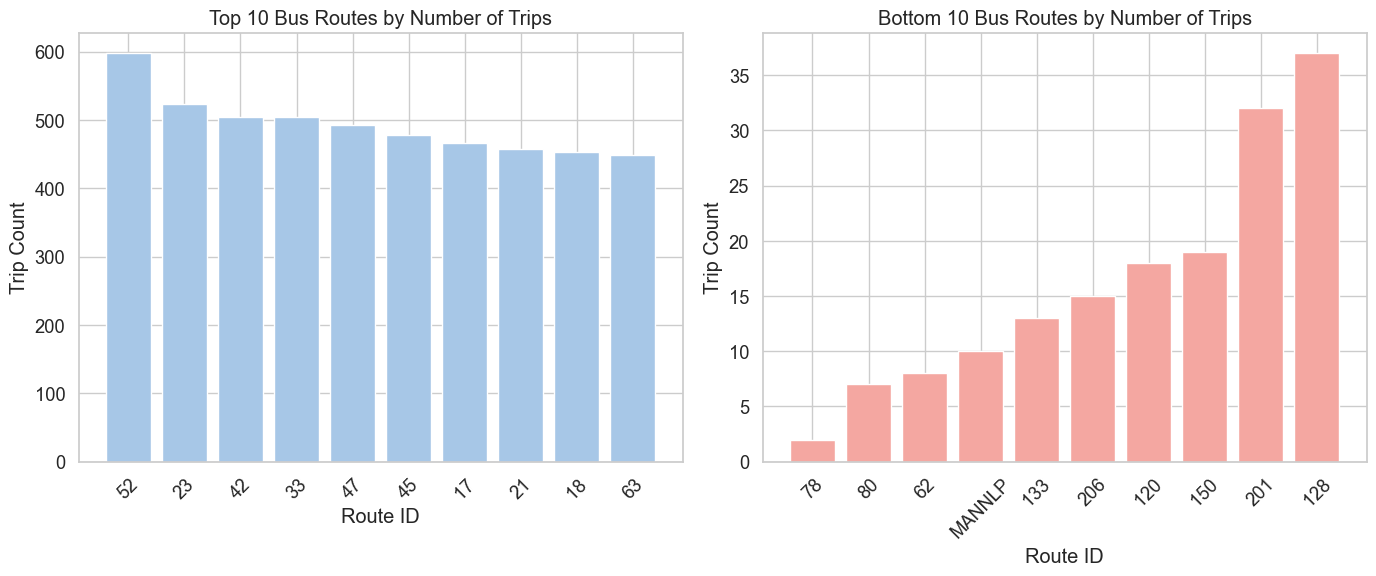

In [ ]:
sns.set(style="whitegrid", font_scale=1.2)

sns.set(style="whitegrid", font_scale=1.2)

fig, axes = plt.subplots(1, 2, figsize=(14,6))

color_top = "#A7C7E7"  
color_bottom = "#F4A7A1"  

axes[0].bar(top10_trips.index.astype(str), top10_trips.values, color=color_top)
axes[0].set_title("Top 10 Bus Routes by Number of Trips")
axes[0].set_xlabel("Route ID")
axes[0].set_ylabel("Trip Count")
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(bottom10_trips.index.astype(str), bottom10_trips.values, color=color_bottom)
axes[1].set_title("Bottom 10 Bus Routes by Number of Trips")
axes[1].set_xlabel("Route ID")
axes[1].set_ylabel("Trip Count")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

<br>
In this section, we summarize the baseline characteristics of SEPTA’s bus network by using the pre-cut GTFS data to calculate the total number of scheduled trips for each route. This allows us to identify the ten routes with the highest service frequency as well as the ten routes with the lowest. These baseline results are not intended as the main analytical focus; rather, they provide an essential reference point for understanding the structure of the system prior to any service reductions and help contextualize the comparisons that follow. In the next section, we compare these original trip counts with the magnitude of headway increases under the proposed service cuts to assess whether reductions are concentrated on high-frequency core routes or disproportionately targeted toward routes that already operate with relatively low service levels.

#### Service reduction data analysis

For the service reduction analysis, we rely on the SEPTA_reschedule dataset obtained directly from SEPTA’s official website. Our primary focus is on changes in headways, as this metric most directly reflects the practical impact of reduced service frequency on riders. Other forms of service modification—such as the complete elimination of specific bus routes—are not included in the scope of this study. Following the proposed service cuts, several routes exhibit noticeably longer headways during both peak periods and midday hours. To understand the spatial implications of these changes, we examine which census tracts are served by routes that experience substantial increases in headways across the two time periods. Census tracts covered by routes with the most significant headway increases are considered to be among the areas most affected by the service reductions.

In [ ]:
speta_reschedule=pd.read_csv("../Python_FinalProject/Dataset/Septa_reschedule.csv")
speta_redchedule_geo=gpd.read_file("../Python_FinalProject/Dataset/SEPTA.gpkg")

In [5]:
speta_redchedule_geo.head()

,line_name,Line,Change,Trunc_Sub,Sched_Redu,Change2,Trunc_Sub2,Sched_Red2,Shape__Length,Cut1_Notes,Cut2_Notes,Mode,Change_subcategory,GlobalID,geometry
0,Route 103: Ardmore to 69th St TC,103,None,Retain,Yes,Route Discontinued,Eliminate,No,39675.938101,Service on Route 103 will be reduced by up to ...,Route 103 will be discontinued. Route 105 will...,Bus,Eliminated Routes and Segments,d5d43eec-efb5-4336-98bd-252c46faded7,"MULTILINESTRING ((2666855.961 238795.427, 2667..."
1,Route 104: West Chester University to 69th St ...,104,None,Retain,Yes,Service Reduction,Retain,Yes,197562.745627,Service on Route 104 will be reduced by up to ...,Reduced service introduced in August 2025 will...,Bus,Service Reduction,bbaaf1f3-70b8-4c6b-a2db-043759636557,"MULTILINESTRING ((2571220.75 232908.944, 25716..."
2,Route 105: 69th St Transit Center to Paoli,105,Alignment,Retain,No,Route Realigned,Retain,No,73423.401500,Route 105 & 106 will be combined into one rout...,Service realignment introduced in August 2025 ...,Bus,Route Realigned,dfa33c4e-3e9a-41ec-8de5-1b4600538a06,"MULTILINESTRING ((2666926.198 239215.025, 2666..."
3,Route 107: Lawrence Park to 69th St TC,107,None,Retain,No,None,Retain,No,97303.281402,No change.,No change.,Bus,None,3cc4f388-8595-40b1-84b0-ec4f1a3f0fd1,"MULTILINESTRING ((2655262.418 216198.573, 2655..."
4,Route 108: UPS or Airport to 69th St TC,108,None,Retain,Yes,Service Reduction,Retain,Yes,108701.037900,Service on Route 108 will be reduced by up to ...,Reduced service introduced in August 2025 will...,Bus,Service Reduction,d475f660-b6ae-48b8-9eb1-22d1a31af5ed,"MULTILINESTRING ((2667821.545 201153.157, 2667..."


<br>
We primarily focus on rows where the `sched_Redu` column equals "Yes," indicating that their schedules have been reduced.
Through regular expression processing, we extract information from `Cut1_Notes` regarding increased peak or midday headway hours and organize it into a new column.
<br>

In [ ]:
speta_reschedule = speta_reschedule[speta_reschedule["Sched_Redu"] == "Yes"]
speta_reschedule.head()

,OID_,line_name,Line,Change,Trunc_Sub,Sched_Redu,Change2,Trunc_Sub2,Sched_Red2,Shape__Length,Cut1_Notes,Cut2_Notes,Mode,Change_subcategory,GlobalID
0,1,Route 103: Ardmore to 69th St TC,103,NaN,Retain,Yes,Route Discontinued,Eliminate,No,39675.938101,Service on Route 103 will be reduced by up to ...,Route 103 will be discontinued. Route 105 will...,Bus,Eliminated Routes and Segments,d5d43eec-efb5-4336-98bd-252c46faded7
1,2,Route 104: West Chester University to 69th St ...,104,NaN,Retain,Yes,Service Reduction,Retain,Yes,197562.745627,Service on Route 104 will be reduced by up to ...,Reduced service introduced in August 2025 will...,Bus,Service Reduction,bbaaf1f3-70b8-4c6b-a2db-043759636557
4,5,Route 108: UPS or Airport to 69th St TC,108,NaN,Retain,Yes,Service Reduction,Retain,Yes,108701.037900,Service on Route 108 will be reduced by up to ...,Reduced service introduced in August 2025 will...,Bus,Service Reduction,d475f660-b6ae-48b8-9eb1-22d1a31af5ed
5,6,Route 109: Chester Transit Center to 69th St T...,109,NaN,Retain,Yes,Service Reduction,Retain,Yes,67324.273894,Service on Route 109 will be reduced by up to ...,Reduced service introduced in August 2025 will...,Bus,Service Reduction,4d92df9a-1dff-421a-a685-b7faa6a1c402
6,7,Route 110: Penn State U to 69th St TC,110,NaN,Retain,Yes,Service Reduction,Retain,Yes,110949.826787,Service on Route 110 will be reduced by up to ...,Reduced service introduced in August 2025 will...,Bus,Service Reduction,c3c1bda9-9a12-42e0-ac17-edc32e2e392f


In [ ]:
re_reduced = re.compile(r"reduced by up to (\d+)", re.I)
re_peak    = re.compile(r"Peak headways will go from (\d+) to (\d+)", re.I)
re_midday  = re.compile(r"Midday headways will go from (\d+) to (\d+)", re.I)

In [8]:
notes_col = "Cut1_Notes"

In [ ]:
def fill_from_notes(row):
    """Extract numeric info from the Cut1_Notes column and fill new fields."""
    text = str(row[notes_col])

    m = re_reduced.search(text)
    if m:
        row["Reduced by"] = int(m.group(1))

    m = re_peak.search(text)
    if m:
        row["Peak headways(O) (mins)"] = int(m.group(1))
        row["Peak headways(C) (mins)"] = int(m.group(2))

    m = re_midday.search(text)
    if m:
        row["Midday headways(O) (mins)"] = int(m.group(1))
        row["Midday headways(C) (mins)"] = int(m.group(2))

    return row

In [10]:
speta_reschedule_output= speta_reschedule.apply(fill_from_notes, axis=1)
speta_reschedule_output.head()

,Change,Change2,Change_subcategory,Cut1_Notes,Cut2_Notes,GlobalID,Line,Midday headways(C) (mins),Midday headways(O) (mins),Mode,OID_,Peak headways(C) (mins),Peak headways(O) (mins),Reduced by,Sched_Red2,Sched_Redu,Shape__Length,Trunc_Sub,Trunc_Sub2,line_name
0,NaN,Route Discontinued,Eliminated Routes and Segments,Service on Route 103 will be reduced by up to ...,Route 103 will be discontinued. Route 105 will...,d5d43eec-efb5-4336-98bd-252c46faded7,103,NaN,NaN,Bus,1,40.0,30.0,20.0,No,Yes,39675.938101,Retain,Eliminate,Route 103: Ardmore to 69th St TC
1,NaN,Service Reduction,Service Reduction,Service on Route 104 will be reduced by up to ...,Reduced service introduced in August 2025 will...,bbaaf1f3-70b8-4c6b-a2db-043759636557,104,40.0,30.0,Bus,2,NaN,NaN,20.0,Yes,Yes,197562.745627,Retain,Retain,Route 104: West Chester University to 69th St ...
4,NaN,Service Reduction,Service Reduction,Service on Route 108 will be reduced by up to ...,Reduced service introduced in August 2025 will...,d475f660-b6ae-48b8-9eb1-22d1a31af5ed,108,20.0,15.0,Bus,5,20.0,15.0,20.0,Yes,Yes,108701.037900,Retain,Retain,Route 108: UPS or Airport to 69th St TC
5,NaN,Service Reduction,Service Reduction,Service on Route 109 will be reduced by up to ...,Reduced service introduced in August 2025 will...,4d92df9a-1dff-421a-a685-b7faa6a1c402,109,30.0,20.0,Bus,6,20.0,15.0,20.0,Yes,Yes,67324.273894,Retain,Retain,Route 109: Chester Transit Center to 69th St T...
6,NaN,Service Reduction,Service Reduction,Service on Route 110 will be reduced by up to ...,Reduced service introduced in August 2025 will...,c3c1bda9-9a12-42e0-ac17-edc32e2e392f,110,40.0,30.0,Bus,7,40.0,30.0,20.0,Yes,Yes,110949.826787,Retain,Retain,Route 110: Penn State U to 69th St TC


In [ ]:
# output_path = "../Python_FinalProject/Dataset/Septa_reschedule_output.csv"
# speta_reschedule_output.to_csv(output_path, index=False, encoding="latin1")

In [12]:
speta_reschedule_output["Difference in Midday headways"] = (
    speta_reschedule_output["Midday headways(C) (mins)"] -
    speta_reschedule_output["Midday headways(O) (mins)"]
)

speta_reschedule_output["Difference in Peak headways"] = (
    speta_reschedule_output["Peak headways(C) (mins)"] -
    speta_reschedule_output["Peak headways(O) (mins)"]
)

In [13]:
speta_reschedule_output

,Change,Change2,Change_subcategory,Cut1_Notes,Cut2_Notes,GlobalID,Line,Midday headways(C) (mins),Midday headways(O) (mins),Mode,...,Peak headways(O) (mins),Reduced by,Sched_Red2,Sched_Redu,Shape__Length,Trunc_Sub,Trunc_Sub2,line_name,Difference in Midday headways,Difference in Peak headways
0,NaN,Route Discontinued,Eliminated Routes and Segments,Service on Route 103 will be reduced by up to ...,Route 103 will be discontinued. Route 105 will...,d5d43eec-efb5-4336-98bd-252c46faded7,103,NaN,NaN,Bus,...,30.0,20.0,No,Yes,39675.938101,Retain,Eliminate,Route 103: Ardmore to 69th St TC,NaN,10.0
1,NaN,Service Reduction,Service Reduction,Service on Route 104 will be reduced by up to ...,Reduced service introduced in August 2025 will...,bbaaf1f3-70b8-4c6b-a2db-043759636557,104,40.0,30.0,Bus,...,NaN,20.0,Yes,Yes,197562.745627,Retain,Retain,Route 104: West Chester University to 69th St ...,10.0,NaN
4,NaN,Service Reduction,Service Reduction,Service on Route 108 will be reduced by up to ...,Reduced service introduced in August 2025 will...,d475f660-b6ae-48b8-9eb1-22d1a31af5ed,108,20.0,15.0,Bus,...,15.0,20.0,Yes,Yes,108701.037900,Retain,Retain,Route 108: UPS or Airport to 69th St TC,5.0,5.0
5,NaN,Service Reduction,Service Reduction,Service on Route 109 will be reduced by up to ...,Reduced service introduced in August 2025 will...,4d92df9a-1dff-421a-a685-b7faa6a1c402,109,30.0,20.0,Bus,...,15.0,20.0,Yes,Yes,67324.273894,Retain,Retain,Route 109: Chester Transit Center to 69th St T...,10.0,5.0
6,NaN,Service Reduction,Service Reduction,Service on Route 110 will be reduced by up to ...,Reduced service introduced in August 2025 will...,c3c1bda9-9a12-42e0-ac17-edc32e2e392f,110,40.0,30.0,Bus,...,30.0,20.0,Yes,Yes,110949.826787,Retain,Retain,Route 110: Penn State U to 69th St TC,10.0,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169,Alignment,Route Realigned,Eliminated Routes and Segments,Route 64 will be realigned along Grays Ferry A...,Reduced service introduced in August 2025 will...,8c07566e-bee2-4d01-9b62-12f4a9aa2e27,64,30.0,20.0,Bus,...,12.0,20.0,Yes,Yes,2534.644123,Eliminate,Eliminate,Route 64: 50th-Parkside to Pier 70,10.0,3.0
170,Alignment,Service Reduction,Eliminated Routes and Segments,"Route 98 will be shortened, and all service wi...",Reduced service introduced in August 2025 will...,fda8ccaa-0b57-45de-8258-b6c40ddba1ba,98,NaN,NaN,Bus,...,30.0,20.0,Yes,Yes,6780.974531,Eliminate,Eliminate,Route 98: Plymouth Meeting to Norristown Trans...,NaN,10.0
173,NaN,Service Reduction,Service Reduction,Service on Route 114 will be reduced by up to ...,Reduced service introduced in August 2025 will...,b9c5adb3-0510-4fb6-a109-02378daaeab0,114,40.0,30.0,Bus,...,NaN,20.0,Yes,Yes,3879.170992,Retain,Retain,Route 114: Wawa Railroad Station to Darby Tran...,10.0,NaN
175,Alignment,Route Realigned,Route Realigned,Route 53 will operate part of the Route 89 to ...,Reduced service introduced in August 2025 will...,49a2147e-4a58-4d5f-aee6-8b815a14a0a0,53,NaN,NaN,Bus,...,20.0,20.0,Yes,Yes,43841.335889,Retain,Retain,Route 53: Wayne-Carpenter to Broad-Hunting Pk,NaN,10.0


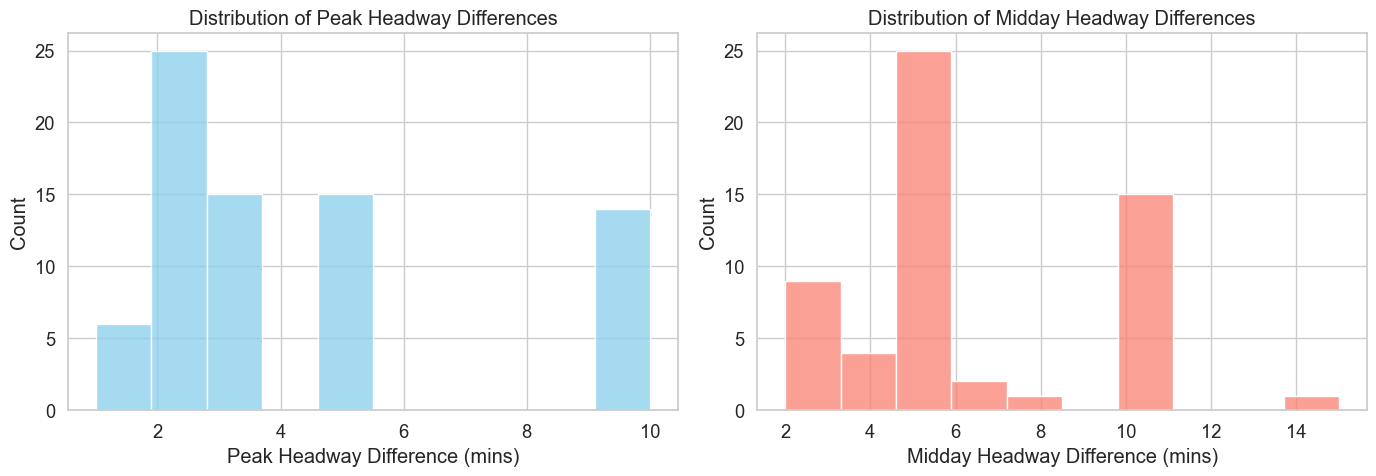

In [14]:
sns.set(style="whitegrid", font_scale=1.2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- Left: Peak Headway Difference ----
sns.histplot(
    speta_reschedule_output["Difference in Peak headways"].dropna(),
    bins=10,
    color="skyblue",
    kde=False,
    ax=axes[0]
)
axes[0].set_title("Distribution of Peak Headway Differences")
axes[0].set_xlabel("Peak Headway Difference (mins)")
axes[0].set_ylabel("Count")

# ---- Right: Midday Headway Difference ----
sns.histplot(
    speta_reschedule_output["Difference in Midday headways"].dropna(),
    bins=10,
    color="salmon",
    kde=False,
    ax=axes[1]
)
axes[1].set_title("Distribution of Midday Headway Differences")
axes[1].set_xlabel("Midday Headway Difference (mins)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

Figure 1 illustrates the distribution of peak-period headway differences across all routes following the proposed service cuts. The majority of routes experience relatively modest increases in headways, most commonly within the range of two to five minutes. Only a small number of routes show much larger increases, such as ten minutes, but these are exceptions rather than the norm. Overall, the distribution is fairly compact, and the absence of extreme outliers suggests that SEPTA’s service reductions during peak hours were implemented in a relatively uniform manner. This pattern indicates that, for most riders traveling during peak periods, the impact of the cuts is limited to a moderate increase in wait times of approximately two to five minutes.

Figure 2 presents the distribution of midday headway differences, which contrasts noticeably with the peak-period pattern. Midday headway changes are more widely dispersed, with several routes experiencing substantially longer increases—some reaching ten minutes and, in a few cases, as high as fourteen to fifteen minutes. While many routes still fall within a moderate five- to six-minute increase range, the distribution exhibits a considerably longer tail, indicating greater variability in the extent of service reduction. This suggests that midday service was adjusted less uniformly than peak service, and certain routes experienced far more significant reductions in frequency during the midday period.

In [94]:
peak_only = speta_reschedule_output[
    speta_reschedule_output["Difference in Peak headways"] >= 5
][["Line", "line_name", "Difference in Peak headways"]]
peak_only

,Line,line_name,Difference in Peak headways
0,103,Route 103: Ardmore to 69th St TC,10.0
4,108,Route 108: UPS or Airport to 69th St TC,5.0
5,109,Route 109: Chester Transit Center to 69th St T...,5.0
6,110,Route 110: Penn State U to 69th St TC,10.0
7,111,Route 111: Chadds Ford to 69th St TC,10.0
8,112,Route 112: Delaware County Community College t...,10.0
9,113,Route 113: Claymont Transit Center to 69th St ...,5.0
13,117,Route 117: Penn State University to I-95 Indus...,10.0
14,118,Route 118: Newtown Square to Chester TC,10.0
24,131,Route 131: Audubon to Norristown TC,10.0


In [95]:
mid_only = speta_reschedule_output[
    speta_reschedule_output["Difference in Midday headways"] >=10
][["Line", "line_name", "Difference in Midday headways"]]
mid_only

,Line,line_name,Difference in Midday headways
1,104,Route 104: West Chester University to 69th St ...,10.0
5,109,Route 109: Chester Transit Center to 69th St T...,10.0
6,110,Route 110: Penn State U to 69th St TC,10.0
7,111,Route 111: Chadds Ford to 69th St TC,15.0
10,114,Route 114: Wawa Railroad Station to Darby Tran...,10.0
16,123,Route 123: King of Prussia to 69th St TC,10.0
45,29,Route 29: Pier 70 to 33rd-Dickinson,10.0
51,38,Route 38: 5th-Market to Wissahickon Transit Ce...,10.0
76,59,Route 59: Castor-Bustleton to Arrott TC,10.0
84,64,Route 64: 50th-Parkside to Pier 70,10.0


To determine whether service reductions disproportionately affected the system’s highest-frequency core routes, we compared the “top ten most frequent routes” and “bottom ten least frequent routes” identified in Section 2.1 with the routes exhibiting the largest increases in headways in this section. The results indicate that the routes experiencing the most substantial reductions—defined here as increases of more than five minutes during peak periods or more than ten minutes during midday—are generally not among the system’s highest-frequency routes. Instead, many of the most affected routes (including 103, 110, 111, 112, 117, 118, 131, 93, 96, 98, and 99) are medium- to low-frequency suburban corridors. In contrast, major high-frequency trunk routes such as 52, 23, 42, and 33 do not appear in the list of severely reduced services. Overall, the findings suggest that the service cuts were not concentrated on the core, high-frequency network; rather, they tended to fall more heavily on routes that already operated with relatively lower baseline frequencies and are located toward the periphery of the system.

In [ ]:
cols_to_add = [
    "Reduced by",
    "Peak headways(O) (mins)",
    "Peak headways(C) (mins)",
    "Midday headways(O) (mins)",
    "Midday headways(C) (mins)",
    "Difference in Midday headways",
    "Difference in Peak headways"
]
speta_reschedule_output_add = speta_reschedule_output[["GlobalID"] + cols_to_add]

In [17]:
reschedule_result = speta_redchedule_geo.merge(speta_reschedule_output_add, on="GlobalID", how="left")
reschedule_result

,line_name,Line,Change,Trunc_Sub,Sched_Redu,Change2,Trunc_Sub2,Sched_Red2,Shape__Length,Cut1_Notes,...,Change_subcategory,GlobalID,geometry,Reduced by,Peak headways(O) (mins),Peak headways(C) (mins),Midday headways(O) (mins),Midday headways(C) (mins),Difference in Midday headways,Difference in Peak headways
0,Route 103: Ardmore to 69th St TC,103,None,Retain,Yes,Route Discontinued,Eliminate,No,39675.938101,Service on Route 103 will be reduced by up to ...,...,Eliminated Routes and Segments,d5d43eec-efb5-4336-98bd-252c46faded7,"MULTILINESTRING ((2666855.961 238795.427, 2667...",20.0,30.0,40.0,NaN,NaN,NaN,10.0
1,Route 104: West Chester University to 69th St ...,104,None,Retain,Yes,Service Reduction,Retain,Yes,197562.745627,Service on Route 104 will be reduced by up to ...,...,Service Reduction,bbaaf1f3-70b8-4c6b-a2db-043759636557,"MULTILINESTRING ((2571220.75 232908.944, 25716...",20.0,NaN,NaN,30.0,40.0,10.0,NaN
2,Route 105: 69th St Transit Center to Paoli,105,Alignment,Retain,No,Route Realigned,Retain,No,73423.401500,Route 105 & 106 will be combined into one rout...,...,Route Realigned,dfa33c4e-3e9a-41ec-8de5-1b4600538a06,"MULTILINESTRING ((2666926.198 239215.025, 2666...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Route 107: Lawrence Park to 69th St TC,107,None,Retain,No,None,Retain,No,97303.281402,No change.,...,None,3cc4f388-8595-40b1-84b0-ec4f1a3f0fd1,"MULTILINESTRING ((2655262.418 216198.573, 2655...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Route 108: UPS or Airport to 69th St TC,108,None,Retain,Yes,Service Reduction,Retain,Yes,108701.037900,Service on Route 108 will be reduced by up to ...,...,Service Reduction,d475f660-b6ae-48b8-9eb1-22d1a31af5ed,"MULTILINESTRING ((2667821.545 201153.157, 2667...",20.0,15.0,20.0,15.0,20.0,5.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,Route 53: Wayne-Carpenter to Broad-Hunting Pk,53,Alignment,Retain,Yes,Route Realigned,Retain,Yes,43841.335889,Route 53 will operate part of the Route 89 to ...,...,Route Realigned,49a2147e-4a58-4d5f-aee6-8b815a14a0a0,"MULTILINESTRING ((2711235.41 248246.58, 271122...",20.0,20.0,30.0,NaN,NaN,NaN,10.0
176,Route 53: Wayne-Carpenter to Broad-Hunting Pk,53,Alignment,Eliminate,Yes,Route Realigned,Eliminate,Yes,2529.977750,Route 53 will operate part of the Route 89 to ...,...,Eliminated Routes and Segments,04468abe-9afd-4912-bf20-e22db7d5b0f9,"MULTILINESTRING ((2698564.372 258554.049, 2697...",20.0,20.0,30.0,NaN,NaN,NaN,10.0
177,Route 125: KOP Business Park to 30th Street St...,125,Route Shortened,Eliminate,No,Route Shortened,Eliminate,No,2650.669713,Route 125 will be shortened to operate between...,...,Eliminated Routes and Segments,d7abd08b-fc40-419f-aa59-c4c51ec5a620,"MULTILINESTRING ((2619722.898 288606.22, 26196...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
178,Route 310: Horsham Breeze,310,Alignment,Eliminate,No,Route Realigned,Eliminate,No,4664.411902,Route 310 will be realigned to provide servic...,...,Eliminated Routes and Segments,10bba5e2-ebfc-42d4-8b2b-afb6f9c1c442,"MULTILINESTRING ((2704664.083 305235.631, 2704...",NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Spatial visualization analysis of bus route reduction

In [65]:
res_gdf = reschedule_result.to_crs(epsg=4326)

In [ ]:
res_gdf_peak = res_gdf.dropna(subset=["Difference in Peak headways"])

peak_map = res_gdf_peak.explore(
    column="Difference in Peak headways",
    cmap="RdPu",                      
    tooltip=["line_name", "Difference in Peak headways"],
    popup=True,
    legend=True,
    style_kwds={"weight": 1},         
    tiles="CartoDB Positron",    
    name="Peak Headway Difference"
)

peak_map

This map shows the spatial distribution of peak headway difference for various bus routes across the city. It reveals that service reductions are not uniform: routes around the city center are mostly light pink, experiencing only a slight extension of 1–3 minutes; while longer routes from the city outskirts and suburbs to the city center are significantly darker, forming several continuous dark pink-purple corridors, indicating substantial reductions of 6–9 minutes or more. Overall, reductions are more concentrated in peripheral areas with high inter-district commuting demand and fewer alternative modes of transportation, while major routes in the core urban area are relatively prioritized for preservation.

In [ ]:
res_gdf_mid = res_gdf.dropna(subset=["Difference in Midday headways"])

mid_map = res_gdf_mid.explore(
    column="Difference in Midday headways",
    cmap="RdPu",
    tooltip=["line_name", "Difference in Midday headways"],
    legend=True,
    tiles="CartoDB Positron",    
    style_kwds={"weight": 1}
)

mid_map

This map shows the spatial distribution of peak headway difference for various bus routes across the city. It reveals that service reductions are not uniform: routes around the city center are mostly light pink, experiencing only a slight extension of 1–3 minutes; while longer routes from the city outskirts and suburbs to the city center are significantly darker, forming several continuous dark pink-purple corridors, indicating substantial reductions of 6–9 minutes or more. Overall, reductions are more concentrated in peripheral areas with high inter-district commuting demand and fewer alternative modes of transportation, while major routes in the core urban area are relatively prioritized for preservation.

In this section, we systematically organized the SEPTA_reschedule data from the official SEPTA website and extracted, cleaned, and analyzed the most critical variable in the service adjustments—**headways**. Through regular expression parsing of text fields, we successfully extracted Peak headways and Midday headways from the route descriptions before and after service reductions and calculated their differences. These differences reflect the changes in operational intensity for different routes after service reductions, laying a data foundation for identifying geographically significantly affected areas.

Simultaneously, we merged the organized CSV data with the route spatial information from GeoPackage (GPKG), providing each route with complete geographic geometry information. This allows us to spatially identify which census tracts are affected by the increased headway due to service reductions, providing crucial data support for subsequent map visualization and spatial inequality analysis. We then used an interactive map to visualize the affected routes, interactively displaying which route was affected and by what extent.

#### Obtain ACScensus tract related population data via API

In [18]:
import cenpy as cenpy
acs = cenpy.remote.APIConnection("ACSDT5Y2021")
acs.variables.head(n=5)

C:\Users\Eilleen\anaconda3\envs\geospatial\lib\site-packages\fuzzywuzzy\fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


,label,concept,predicateType,group,limit,predicateOnly,hasGeoCollectionSupport,attributes,required
for,Census API FIPS 'for' clause,Census API Geography Specification,fips-for,N/A,0,True,NaN,NaN,NaN
in,Census API FIPS 'in' clause,Census API Geography Specification,fips-in,N/A,0,True,NaN,NaN,NaN
ucgid,Uniform Census Geography Identifier clause,Census API Geography Specification,ucgid,N/A,0,True,True,NaN,NaN
B24022_060E,Estimate!!Total:!!Female:!!Service occupations...,SEX BY OCCUPATION AND MEDIAN EARNINGS IN THE P...,int,B24022,0,NaN,NaN,"B24022_060EA,B24022_060M,B24022_060MA",NaN
B19001B_014E,"Estimate!!Total:!!$100,000 to $124,999",HOUSEHOLD INCOME IN THE PAST 12 MONTHS (IN 202...,int,B19001B,0,NaN,NaN,"B19001B_014EA,B19001B_014M,B19001B_014MA",NaN


In [19]:
variables = ["NAME", "B19013_001E"]
income = acs.query(
    cols=["NAME", "B19013_001E"],
    geo_unit="tract",
    geo_filter={"state": "42", "county": "101"}
)
income.head()


transit = acs.query(
    cols=["NAME", "B08301_001E", "B08301_010E"],
    geo_unit="tract",
    geo_filter={"state": "42", "county": "101"}   
)

In [20]:
import pygris
tracts = pygris.tracts(state="PA", county="101", year=2021)
tracts.head()

Using FIPS code '42' for input 'PA'


,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
68,42,101,039100,42101039100,391,Census Tract 391,G5020,S,1119799,133239,+39.9332720,-075.2132103,"POLYGON ((-75.22235 39.93105, -75.22129 39.931..."
69,42,101,980902,42101980902,9809.02,Census Tract 9809.02,G5020,S,132548,50536,+39.9346276,-075.2046321,"POLYGON ((-75.20684 39.93409, -75.20655 39.934..."
70,42,101,980904,42101980904,9809.04,Census Tract 9809.04,G5020,S,1570844,158459,+39.9247300,-075.2036710,"POLYGON ((-75.21243 39.92523, -75.2113 39.9284..."
71,42,101,980903,42101980903,9809.03,Census Tract 9809.03,G5020,S,171154,0,+39.9347932,-075.2009884,"POLYGON ((-75.20422 39.93285, -75.20305 39.934..."
72,42,101,980906,42101980906,9809.06,Census Tract 9809.06,G5020,S,2945390,383112,+39.9095823,-075.1984052,"POLYGON ((-75.21612 39.90964, -75.21454 39.910..."


In [21]:
income["GEOID"] = (
    income["state"].astype(str).str.zfill(2) +
    income["county"].astype(str).str.zfill(3) +
    income["tract"].astype(str).str.zfill(6)
)
income.head()

transit["GEOID"] = (
    transit["state"].astype(str).str.zfill(2) +
    transit["county"].astype(str).str.zfill(3) +
    transit["tract"].astype(str).str.zfill(6)
)

In [22]:
#Income data with geometry
income_geo = tracts.merge(income, on="GEOID")
income_geo["B19013_001E"] = pd.to_numeric(income_geo["B19013_001E"], errors="coerce")
income_geo  = income_geo [income_geo ["B19013_001E"] > 0]


#Transit proportion data with geometry
transit_geo = tracts.merge(transit, on="GEOID")
transit_geo["B08301_010E"] = pd.to_numeric(transit_geo["B08301_010E"], errors="coerce")
transit_geo["B08301_001E"] = pd.to_numeric(transit_geo["B08301_001E"], errors="coerce")
transit_geo["transit_share"] = (
    transit_geo["B08301_010E"] / transit_geo["B08301_001E"]
)

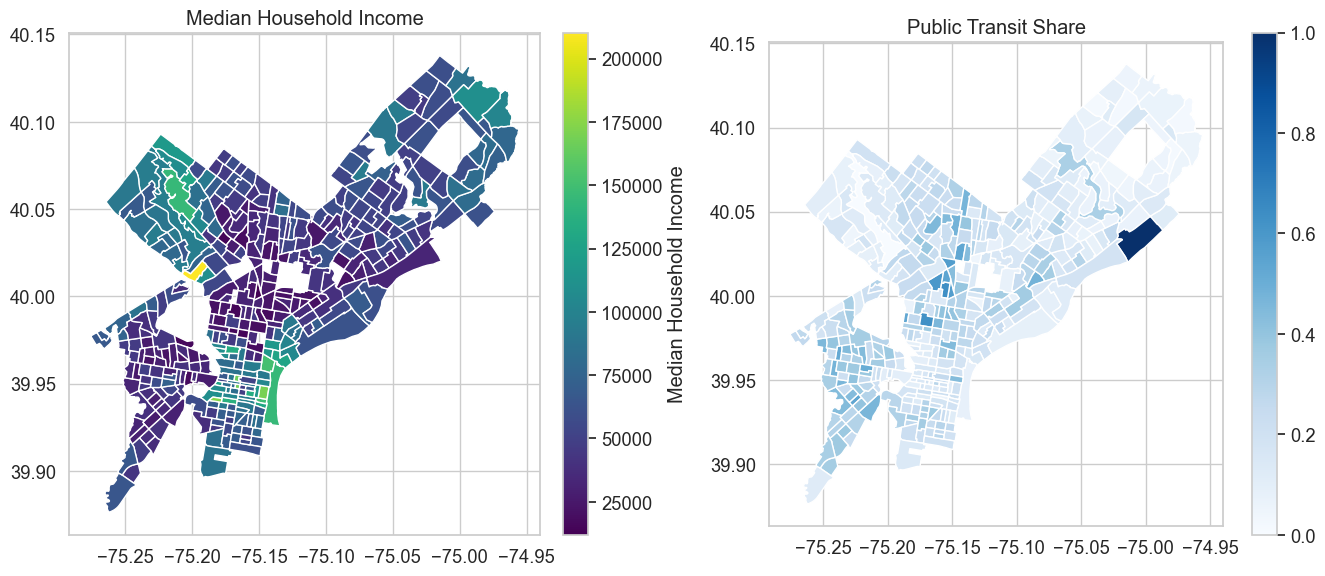

In [ ]:
import matplotlib.ticker as ticker

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

income_ax = axes[0]

income_geo.plot(
    column="B19013_001E",
    cmap="viridis",
    ax=income_ax,
    legend=False
)

income_ax.set_title("Median Household Income")


sm_income = plt.cm.ScalarMappable(
    cmap="viridis",
    norm=plt.Normalize(
        vmin=income_geo["B19013_001E"].min(),
        vmax=income_geo["B19013_001E"].max()
    )
)
sm_income._A = []


cbar_income = fig.colorbar(
    sm_income,
    ax=income_ax,
    orientation='vertical',
    fraction=0.046,
    pad=0.04
)

cbar_income.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))
cbar_income.set_label("Median Household Income")



transit_geo.plot(
    column="transit_share",
    cmap="Blues",
    ax=axes[1],
    legend=True
)
axes[1].set_title("Public Transit Share")

plt.tight_layout()
plt.show()

<br>
These two graphs show that high-income areas are dispersed and have a lower reliance on public transportation, while low-income areas are concentrated and have a higher transit share. They have a slight inverse relationship.

### Part III. A Study on the Distribution of Service Reductions in Cities

#### Spatial Distribution of Income, Transit Dependence, and Headway Reductions

In [ ]:

income_geo = income_geo.to_crs(reschedule_result.crs)
transit_geo = transit_geo.to_crs(reschedule_result.crs)

census = income_geo[["GEOID", "B19013_001E", "geometry"]].merge(
    transit_geo[["GEOID", "transit_share"]],
    on="GEOID",
    how="left"
)

affected = gpd.sjoin(
    census,
    reschedule_result,    
    how="inner",
    predicate="intersects"
)

In [26]:
affected.to_file("../Python_FinalProject/Dataset/affected.geojson", driver="GeoJSON")

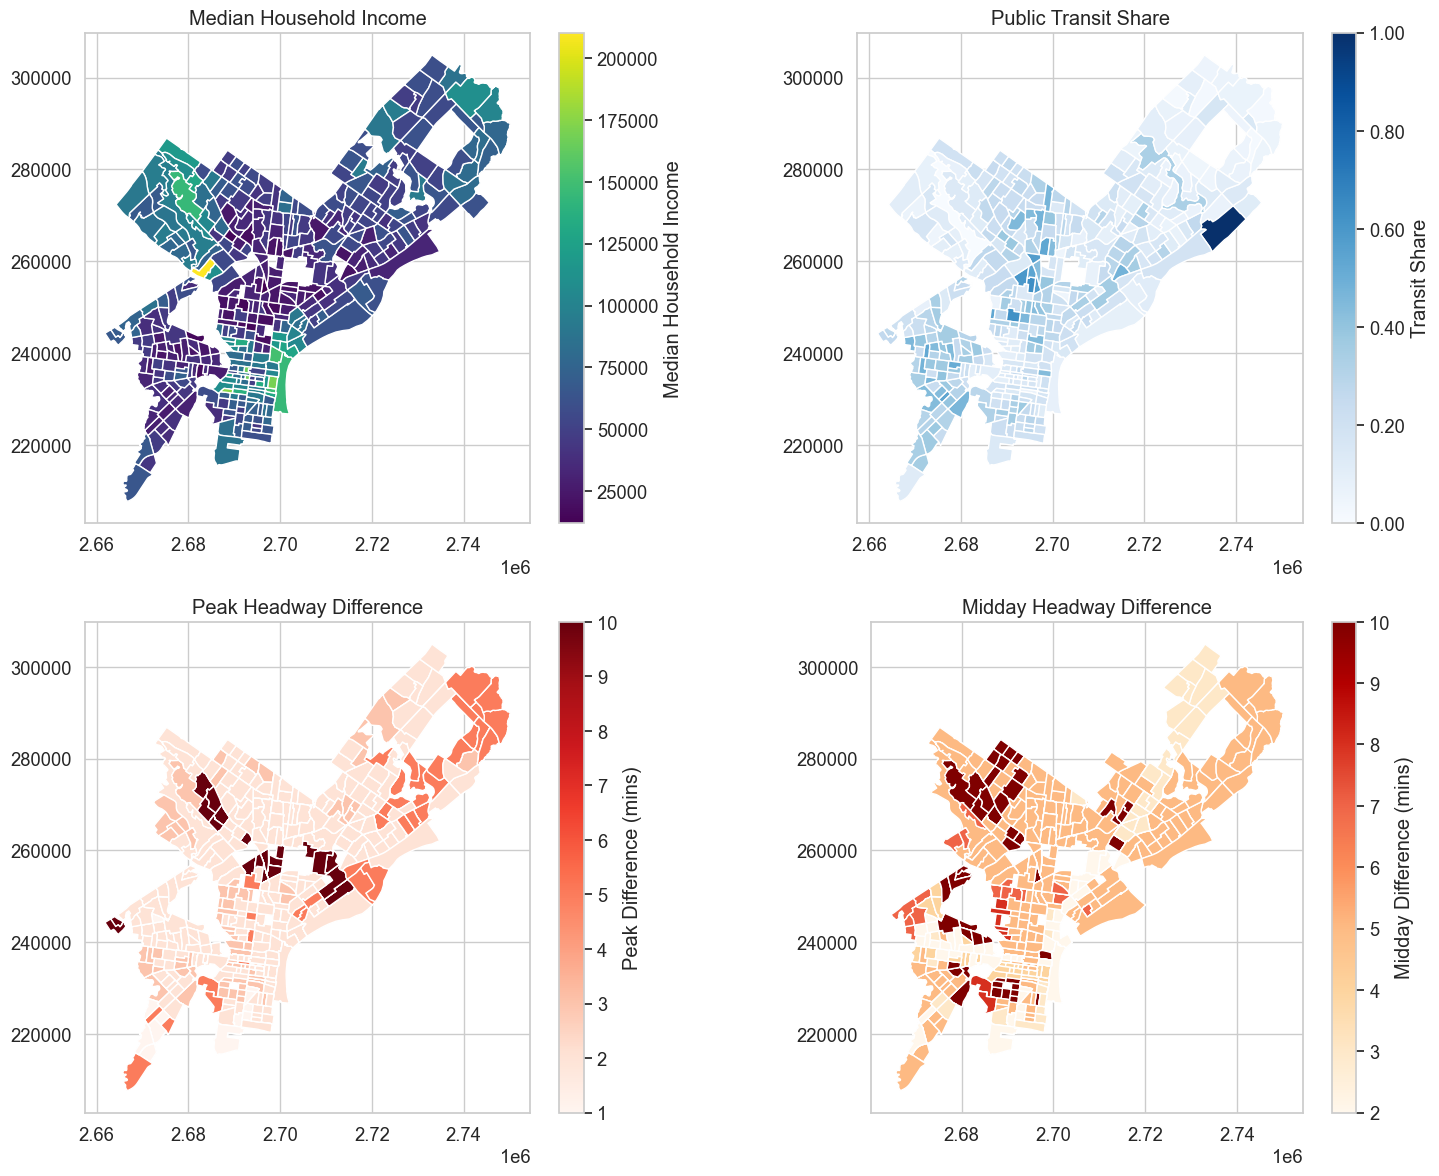

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# =====================================================
# Row 1, Col 1: Income
# =====================================================
income_ax = axes[0, 0]

income_geo.plot(
    column="B19013_001E",
    cmap="viridis",
    ax=income_ax,
    legend=False
)

income_ax.set_title("Median Household Income")

sm_income = plt.cm.ScalarMappable(
    cmap="viridis",
    norm=plt.Normalize(
        vmin=income_geo["B19013_001E"].min(),
        vmax=income_geo["B19013_001E"].max()
    )
)
sm_income._A = []
cbar_income = fig.colorbar(
    sm_income,
    ax=income_ax,
    orientation="vertical",
    fraction=0.046,
    pad=0.04
)
cbar_income.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))
cbar_income.set_label("Median Household Income")


# =====================================================
# Row 1, Col 2: Transit Share
# =====================================================
transit_ax = axes[0, 1]

transit_geo.plot(
    column="transit_share",
    cmap="Blues",
    ax=transit_ax,
    legend=False
)

transit_ax.set_title("Public Transit Share")

sm_transit = plt.cm.ScalarMappable(
    cmap="Blues",
    norm=plt.Normalize(
        vmin=transit_geo["transit_share"].min(),
        vmax=transit_geo["transit_share"].max()
    )
)
sm_transit._A = []
cbar_transit = fig.colorbar(
    sm_transit,
    ax=transit_ax,
    orientation="vertical",
    fraction=0.046,
    pad=0.04
)
cbar_transit.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
cbar_transit.set_label("Transit Share")


# =====================================================
# Row 2, Col 1: Peak Headway Difference
# =====================================================
peak_ax = axes[1, 0]

affected.plot(
    column="Difference in Peak headways",
    cmap="Reds",
    ax=peak_ax,
    legend=False
)

peak_ax.set_title("Peak Headway Difference")

sm_peak = plt.cm.ScalarMappable(
    cmap="Reds",
    norm=plt.Normalize(
        vmin=affected["Difference in Peak headways"].min(),
        vmax=affected["Difference in Peak headways"].max()
    )
)
sm_peak._A = []
cbar_peak = fig.colorbar(
    sm_peak,
    ax=peak_ax,
    orientation="vertical",
    fraction=0.046,
    pad=0.04
)
cbar_peak.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))
cbar_peak.set_label("Peak Difference (mins)")


# =====================================================
# Row 2, Col 2: Midday Headway Difference
# =====================================================
midday_ax = axes[1, 1]

affected.plot(
    column="Difference in Midday headways",
    cmap="OrRd",
    ax=midday_ax,
    legend=False
)

midday_ax.set_title("Midday Headway Difference")

sm_mid = plt.cm.ScalarMappable(
    cmap="OrRd",
    norm=plt.Normalize(
        vmin=affected["Difference in Midday headways"].min(),
        vmax=affected["Difference in Midday headways"].max()
    )
)
sm_mid._A = []
cbar_mid = fig.colorbar(
    sm_mid,
    ax=midday_ax,
    orientation="vertical",
    fraction=0.046,
    pad=0.04
)
cbar_mid.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))
cbar_mid.set_label("Midday Difference (mins)")


plt.tight_layout()
plt.show()

1. Spatial Distribution of Peak Headway Reductions

The map of peak-period headway differences reveals a clear spatial pattern in the distribution of service cuts across Philadelphia. The census tracts experiencing the most substantial increases in peak headways—typically in the range of seven to ten minutes—are concentrated primarily in North Philadelphia, with additional clusters in parts of Southwest Philadelphia and several tracts in the Kensington and Frankford areas. In contrast, higher-income neighborhoods such as Chestnut Hill show comparatively minor increases in headways. This spatial pattern suggests that peak-period service reductions are not evenly distributed across the city; instead, they are more pronounced in communities that have historically faced socioeconomic disadvantages.

2. Midday Reductions Are More Severe and More Uneven

The midday headway difference map shows an even more pronounced and uneven distribution of service cuts compared to the peak period. Midday headways lengthen across a wider swath of the city, with many census tracts in North and South Philadelphia—areas characterized by lower incomes and higher levels of transit dependence—displaying substantial increases of six to ten minutes. The overall pattern indicates that midday service reductions are not only more extensive in geographic coverage but also more severe in magnitude. These findings raise concerns regarding transportation equity, as midday periods are particularly important for riders who work nontraditional hours, hold multiple jobs, or rely on transit for errands, caregiving, and essential daily activities.

3. Cross-Spatial Patterns: Overlap with Low-Income and Transit-Dependent Areas

When the headway reduction maps are compared with the income and transit-dependence maps, a strong spatial overlap becomes evident. Census tracts with the largest increases in both peak and midday headways align closely with areas exhibiting the lowest median household incomes and the highest shares of transit-dependent commuters. This alignment indicates that the service cuts are not spatially neutral; instead, they disproportionately affect communities that are both economically vulnerable and heavily reliant on public transportation. The combined map patterns suggest that SEPTA’s proposed service reductions may inadvertently amplify existing inequities by concentrating the greatest burdens on neighborhoods with the least resilience and the highest mobility needs.

#### Calculate the average income and percentage of public transport use of the affected tracts vs. the citywide average income and percentage of public transport use.

In [ ]:

# Peak difference ≥ 5
significant_peak = affected[affected["Difference in Peak headways"] >= 5]

# Midday difference ≥ 10
significant_midday = affected[affected["Difference in Midday headways"] >= 10]

In [29]:
significant_peak.head()

,GEOID,B19013_001E,geometry,transit_share,index_right,line_name,Line,Change,Trunc_Sub,Sched_Redu,...,Mode,Change_subcategory,GlobalID,Reduced by,Peak headways(O) (mins),Peak headways(C) (mins),Midday headways(O) (mins),Midday headways(C) (mins),Difference in Midday headways,Difference in Peak headways
1,42101036700,150952,"POLYGON ((2697584.351 238202.466, 2697586.8 23...",0.186473,40,Route 25: Frankford Transit Center to Columbus...,25,Alignment,Retain,Yes,...,Bus,Service Reduction,00027c19-8c78-4952-851f-fcefdad95797,20.0,15.0,20.0,NaN,NaN,NaN,5.0
2,42101034702,93397,"POLYGON ((2728000.591 274185.496, 2728021.913 ...",0.100000,35,Route 20: Philadelphia Mills to Frankford Tran...,20,None,Retain,Yes,...,Bus,Service Reduction,ac6cb60d-8099-4579-b2d5-a0e49df3db3f,20.0,15.0,20.0,15.0,20.0,5.0,5.0
3,42101034801,65357,"POLYGON ((2731188.994 276587.436, 2731231.434 ...",0.125530,35,Route 20: Philadelphia Mills to Frankford Tran...,20,None,Retain,Yes,...,Bus,Service Reduction,ac6cb60d-8099-4579-b2d5-a0e49df3db3f,20.0,15.0,20.0,15.0,20.0,5.0,5.0
4,42101034802,52519,"POLYGON ((2731989.002 277695.676, 2732024.434 ...",0.043898,35,Route 20: Philadelphia Mills to Frankford Tran...,20,None,Retain,Yes,...,Bus,Service Reduction,ac6cb60d-8099-4579-b2d5-a0e49df3db3f,20.0,15.0,20.0,15.0,20.0,5.0,5.0
11,42101036000,56250,"POLYGON ((2730983.869 291311.02, 2731828.763 2...",0.167862,35,Route 20: Philadelphia Mills to Frankford Tran...,20,None,Retain,Yes,...,Bus,Service Reduction,ac6cb60d-8099-4579-b2d5-a0e49df3db3f,20.0,15.0,20.0,15.0,20.0,5.0,5.0


In [30]:
peak_income_mean = significant_peak["B19013_001E"].mean()
print("Average income in peak-impacted tracts:", peak_income_mean)
midday_income_mean = significant_midday["B19013_001E"].mean()
print("Average income in midday-impacted tracts:", midday_income_mean)
city_income_mean = income_geo["B19013_001E"].mean()
print("Citywide average income:", city_income_mean)

Average income in peak-impacted tracts: 58521.760765550236
Average income in midday-impacted tracts: 61180.04098360656
Citywide average income: 58714.34293193717


In [31]:
peak_transit_mean = significant_peak["transit_share"].mean()
print("Transit share in peak-impacted tracts:", peak_transit_mean)
midday_transit_mean = significant_midday["transit_share"].mean()
print("Transit share in midday-impacted tracts:", midday_transit_mean)
city_transit_mean = transit_geo["transit_share"].mean()
print("Citywide transit share:", city_transit_mean)

Transit share in peak-impacted tracts: 0.23987480761887164
Transit share in midday-impacted tracts: 0.2610999666141764
Citywide transit share: 0.22858580680494048


Socioeconomic Patterns in Communities Most Impacted by Service Reductions：

A comparison of the census tracts most affected by service reductions shows that income differences across groups are relatively modest. The areas experiencing significant peak headway increases have an average household income of $58,521, which is only slightly lower than the citywide average of $58,714. Meanwhile, the tracts most affected during the midday period have a somewhat higher average income of $61,180. These results suggest that income alone does not strongly correlate with where service cuts occur, and the spatial distribution of reductions cannot be explained simply by differences in household income.

Transit reliance, however, reveals a much clearer and more meaningful pattern. The average transit share in peak-affected tracts is 23.99 percent—higher than the citywide level of 22.86 percent—and the midday-affected areas show an even greater transit share of 26.11 percent. This indicates that communities with higher dependence on public transportation are more likely to experience increased headways under the proposed service cuts. In summary, while income differences appear minimal, the impacts of service reductions are more concentrated in neighborhoods with elevated transit reliance, highlighting the potential for disproportionate burdens on riders who depend most heavily on SEPTA’s bus network.

### Part IV. Traffic reduction impact from an accessibility perspective (Simulation based on OSM network)

This chapter adopts an accessibility perspective to assess the impact of public transport service reductions on residents' travel convenience. Compared to previous chapters that directly analyzed reduced service frequency and increased headway, this chapter focuses on a core question: do service reductions make certain areas of the city more difficult to reach important destinations?

To this end, we construct a simplified accessibility model based on the OSM street network. The model does not directly simulate the complete public transport operation; instead, it treats the increase in headway for each route as additional travel penalty and incorporates these penalties into the network in the form of time costs. This approach is not for calculating precise public transport travel times, but rather to capture the relative changes in "travel difficulty" across urban space after the reductions.

The OSM pedestrian network is used as the underlying structure because this study focuses not on driving behavior, but on changes in accessibility for public transport-dependent groups; driving networks cannot reflect the inconvenience caused by reduced service frequency and increased waiting times. Furthermore, the incomplete GTFS data after the reductions cannot support the construction of a reliable transit network model. Pedestrian networks, as a neutral and stable urban topology, can provide a unified spatial framework, allowing headway penalties to be directly mapped to corresponding areas, thus reflecting the relative impact of reductions on spatial accessibility.

Based on the above methods, we will calculate the shortest travel time to City Hall before and after the reductions, and further compare the differences to identify the most significantly affected areas and observe whether there is spatial overlap between these areas and the distribution of highly reduced routes. The final results will help us understand the potential impact of this public transit adjustment from the perspectives of fairness and spatial structure.

In [101]:
import osmnx as ox
import networkx as nx

#### Download the Philadelphia Walking Network

In [97]:
ox.settings.log_console = False
ox.settings.use_cache = True

In [98]:
G = ox.graph_from_place("Philadelphia, Pennsylvania, USA", network_type="walk")

In [99]:
G

#### Locating City Hall and Identifying the Nearest Network Node

In this step, we identify the geographic position of Philadelphia City Hall and determine the closest corresponding node within the street network graph. This process is essential for establishing a consistent reference point in our accessibility analysis. By converting City Hall’s latitude–longitude coordinates into the nearest network vertex, we ensure that routing and network-based computations originate from a valid and connected point within the OSM-derived street network. This node serves as a central anchor for subsequent calculations, such as estimating reachability and assessing how service reductions may alter the connectivity of different census tracts relative to a major regional destination.

In [100]:
# City Hall coordinates
cityhall_lat = 39.952583
cityhall_lon = -75.165222
origin_point = (cityhall_lat, cityhall_lon)

# Find nearest node in graph
origin_node = ox.distance.nearest_nodes(G, cityhall_lon, cityhall_lat)

origin_node

8328381954

#### Adding Travel Time to the Network and Computing Baseline Accessibility

In this step, we enrich the street network by assigning a travel_time attribute to each edge based on segment length and assumed travel speeds. This transforms the network from a purely spatial representation into a functional model capable of supporting time-based accessibility analysis. Once travel time is incorporated, we compute baseline (before–cut) accessibility by estimating how far a traveler can reach within a given time threshold from City Hall, using the previously identified nearest network node as the origin. This baseline measure provides a reference for understanding normal travel conditions and serves as the foundation for evaluating how accessibility may change under reduced service scenarios.

In [ ]:
for u, v, k, data in G.edges(keys=True, data=True):
    length = data.get("length", 0)
    data["travel_time"] = length / 83.33   # 单位：分钟

In [ ]:
travel_time_before = nx.shortest_path_length(
    G,
    source=origin_node,
    weight="travel_time"
)

In [104]:
travel_time_before = pd.DataFrame.from_dict(
    travel_time_before, orient="index", columns=["time_before"]
)

travel_time_before.head()

,time_before
8328381954,0.000000
6634227387,0.163822
4898480510,0.471477
4898481734,0.503168
8328381959,0.549563


#### Mapping Headway Increases onto the Network as Penalty Values

In this step, we translate the observed increases in headways into penalty values that can be applied to the street network. The idea behind this transformation is to capture the additional waiting time imposed on riders when bus frequencies are reduced. By assigning a penalty to edges associated with routes that experienced significant headway increases, we approximate the diminished convenience and reliability caused by service cuts. These penalties are then incorporated into the travel_time attribute, effectively adjusting the network to reflect conditions under reduced service. This approach allows us to model accessibility in a way that accounts not only for physical travel time but also for the added waiting burden imposed by less frequent transit service.

In [108]:
df = affected

In [ ]:
severe_routes = df[
    (df["Difference in Peak headways"] > 5) |
    (df["Difference in Midday headways"] > 10)
]

severe_routes_list = severe_routes["Line"].astype(str).tolist()
severe_routes_list

['53',
 '53',
 '103',
 '103',
 '53',
 '53',
 '53',
 '53',
 '53',
 '53',
 '53',
 '53',
 '53',
 '53',
 '53',
 '53',
 '53',
 '53',
 '53',
 '53',
 '53',
 '53',
 '53',
 '53',
 '53',
 '53']

In [ ]:
severe_routes_gdf = severe_routes[["Line", "geometry"]].copy()
severe_routes_gdf = gpd.GeoDataFrame(severe_routes_gdf, geometry="geometry", crs="EPSG:2272")

In [ ]:
severe_routes_gdf = severe_routes_gdf.to_crs(epsg=4326)

In [ ]:
nodes, edges = ox.graph_to_gdfs(G, nodes=True, edges=True)

In [ ]:
buffer_dist = 300  # meters

severe_routes_proj = severe_routes_gdf.to_crs(epsg=3857)
severe_buffers = severe_routes_proj.buffer(buffer_dist)


In [ ]:
nodes_proj = nodes.to_crs(epsg=3857)
nodes_in_buffer = nodes_proj[nodes_proj.within(severe_buffers.union_all())]
affected_node_ids = nodes_in_buffer.index.tolist()

#### Assigning Post-Cut Penalty Values to Affected Network Nodes

After establishing penalty values based on headway increases, we assign these penalties to the nodes and edges of the network that fall within the service areas of the most affected routes. This step ensures that the reduced transit frequency is reflected directly in the network’s travel cost structure. Nodes associated with routes that experienced larger headway increases receive proportionally higher penalties, thereby simulating the added waiting time and reduced service reliability that riders would face under the proposed cuts. Incorporating these penalties into the network allows the model to more accurately represent post-cut travel conditions and provides the necessary basis for evaluating how accessibility changes when service reductions are accounted for.

In [ ]:
penalty_minutes = 8

travel_time_after = travel_time_before.copy()

travel_time_after.loc[affected_node_ids, "time_after"] = (
    travel_time_after.loc[affected_node_ids, "time_before"] + penalty_minutes
)

travel_time_after["time_after"] = travel_time_after["time_after"].fillna(travel_time_after["time_before"])
travel_time_after.head()

,time_before,time_after
8328381954,0.000000,0.000000
6634227387,0.163822,0.163822
4898480510,0.471477,0.471477
4898481734,0.503168,0.503168
8328381959,0.549563,0.549563


#### Calculating Changes in Accessibility (Delta Accessibility)

With both the baseline and post-cut travel_time surfaces computed, we then calculate the change in accessibility, or delta accessibility, for each census tract. This involves comparing the number of network nodes reachable within a fixed travel-time threshold before and after penalties are applied. The resulting differences indicate how much accessibility is gained or lost due to the service reductions. Tracts with large negative deltas represent areas where mobility has been meaningfully diminished, while smaller or negligible changes suggest more resilient parts of the system. This comparison provides a direct measure of the spatial impact of service cuts and highlights which communities experience the most substantial decline in reachability under the reduced-service scenario.

In [ ]:
travel_time_after["delta"] = travel_time_after["time_after"] - travel_time_after["time_before"]

travel_time_after.head()

,time_before,time_after,delta
8328381954,0.000000,0.000000,0.0
6634227387,0.163822,0.163822,0.0
4898480510,0.471477,0.471477,0.0
4898481734,0.503168,0.503168,0.0
8328381959,0.549563,0.549563,0.0


In [154]:
top20_affected = travel_time_after.sort_values("delta", ascending=False).head(20)
top20_affected

,time_before,time_after,delta
9332643947,120.743447,128.743447,8.0
12164089308,125.854921,133.854921,8.0
109855180,121.695443,129.695443,8.0
2692917700,125.718856,133.718856,8.0
12563258244,121.701439,129.701439,8.0
6496267328,121.702787,129.702787,8.0
12563447082,121.724332,129.724332,8.0
5543784129,125.781072,133.781072,8.0
4457347529,121.758861,129.758861,8.0
5543784161,125.790623,133.790623,8.0


The deterioration in accessibility caused by the cuts is primarily concentrated in communities further from the city center that rely on suburban transit corridors. These areas already had long base travel times to City Hall, and the extension of the headway further exacerbates their accessibility disadvantages.

#### 4.7 Delta Accessibility Heatmap

In [155]:
nodes_with_delta = nodes.copy()
nodes_with_delta["delta"] = travel_time_after["delta"]
nodes_wgs = nodes_with_delta.to_crs(epsg=4326)

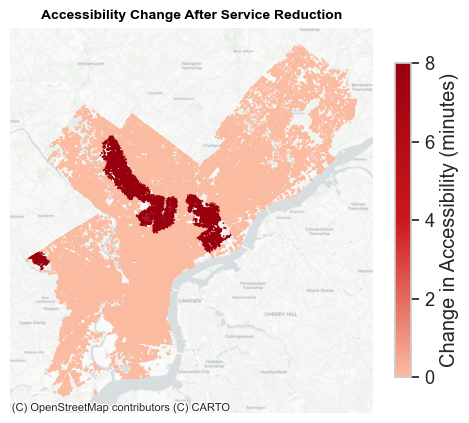

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import contextily as cx

# ------------------------------
red_orange = [
    "#fcbba1",
    "#cb181d",
    "#99000d"
]
red_orange_cmap = mcolors.LinearSegmentedColormap.from_list(
    "redorange", red_orange
)

# ------------------------------
nodes_3857 = nodes_plot.to_crs(epsg=3857)

# ------------------------------
fig, ax = plt.subplots(figsize=(5, 5))

nodes_3857.plot(
    ax=ax,
    column="delta",
    cmap=red_orange_cmap,
    markersize=2,
    edgecolor="none",
    alpha=0.85,
    legend=True,
    legend_kwds={
        "label": "Change in Accessibility (minutes)",
        "orientation": "vertical",
        "shrink": 0.7,
    },
)

cx.add_basemap(
    ax,
    source=cx.providers.CartoDB.Positron,   # 很干净的浅灰底图
    zoom=12,
    alpha=0.9
)

ax.set_title(
    "Accessibility Change After Service Reduction",
    fontsize=10,
    fontweight="bold",
    color="black"
)
ax.set_axis_off()

plt.tight_layout()
plt.show()

From an accessibility perspective, the proposed service reductions do not produce large, systemwide losses in travel time but instead generate a distinct “corridor‐based attenuation pattern.” The decrease in accessibility is concentrated almost entirely within a 300-meter buffer surrounding the most heavily reduced routes, creating continuous impact corridors that trace the alignment of these lines. Areas farther away from the affected routes experience minimal change, and the impact effectively dissipates beyond the immediate service sheds. Because City Hall is used as the sole destination in this analysis, the central districts exhibit virtually no accessibility loss. In contrast, peripheral communities that rely more heavily on cross-district bus travel show notable declines. These include several suburban radial corridors such as the West Philadelphia–Upper Darby axis served by Routes 103, 110, and 111, the Chester and Delaware County corridors associated with Routes 112, 117, and 118, and the Northeast Philadelphia suburban links along Routes 93, 96, 98, and 99. In all of these areas, the increased headways translate into reduced reachability to City Hall within the chosen time threshold. This spatial pattern closely mirrors the distribution of headway differences identified earlier and reinforces the finding that the service reductions disproportionately undermine accessibility in corridors that are already more dependent on the bus network for regional mobility.

#### Limitation

It is important to note that the accessibility analysis in this chapter is based on an OSM-derived street network rather than a true public transit network. Because OSMnx does not include transit routes, operating speeds, transfer structures, or schedule-based connectivity, we approximate the effect of service reductions by assigning penalty values to nodes within affected corridors. This approach allows us to capture the spatial footprint of reduced service but cannot fully represent actual transit-based accessibility changes. As a result, the observed differences in travel times are relatively small and should be interpreted primarily as spatial indicators rather than precise measures of temporal impact.

We also attempted to use R5py—a full-featured public transit accessibility engine built on GTFS and OpenTripPlanner—to model pre- and post-cut accessibility more accurately. However, persistent compatibility issues involving software versions, environmental dependencies, and GTFS calendar interpretation prevented the successful generation of any valid accessibility matrices. This limitation is worth stating explicitly, as extensive debugging efforts were undertaken without resolving these conflicts. Given these constraints, the OSM-based network approach was adopted as a practical alternative for the purposes of this project. Future work conducted in a more stable computing environment, or using mature transit-routing tools such as R5 or OpenTripPlanner, would allow for more accurate modeling of schedule-based accessibility changes and yield results with stronger temporal explanatory power.

### Conclusion, Summary, and Recommendations

This study evaluates the spatial and equity implications of SEPTA’s proposed bus service reductions by examining changes in headways, accessibility, and demographic characteristics across Philadelphia. Although the cuts do not produce dramatic citywide losses in travel time, the results reveal a clear corridor-based pattern in which accessibility declines are concentrated along routes that experienced the most substantial increases in headways. These corridors—primarily suburban radials in Delaware County, Upper Darby, and parts of Northeast Philadelphia—show measurable reductions in reachability to City Hall, while the city center remains largely unaffected. This pattern aligns closely with the distribution of peak and midday headway increases, confirming that service reductions are spatially selective rather than uniformly applied across the network.

From an equity perspective, the findings suggest that income levels alone do not strongly predict exposure to service reductions; affected tracts show only small deviations from citywide averages. Transit dependence, however, emerges as a much stronger indicator. Communities with higher shares of transit-reliant residents are more likely to experience increased headways and corresponding accessibility losses. This raises concerns about potential disproportionate burdens on riders who depend most heavily on the bus system, particularly those traveling during midday periods or working nontraditional hours.

At the methodological level, the limitations of using an OSM-based street network—rather than a full transit network—must be acknowledged. While this approach effectively captures the spatial footprint of reduced service, it cannot fully represent schedule-based accessibility changes. Attempts to employ R5py for a more robust GTFS-integrated analysis were unsuccessful due to persistent software and environment conflicts, constraining the precision of the temporal results. Nonetheless, the spatial patterns identified here remain consistent and meaningful, offering valuable insights for understanding where service cuts are likely to be felt most strongly.

Based on these findings, several recommendations emerge. First, SEPTA could evaluate opportunities to preserve frequency in corridors with high transit dependency, even if systemwide cuts are necessary. Protecting key midday services may be particularly important for riders with nonstandard work schedules. Second, future planning efforts should incorporate equity-focused metrics—such as transit reliance and demographic vulnerability—into prioritization frameworks to avoid disproportionately impacting already disadvantaged communities. Finally, further analysis using stable implementations of R5 or similar transit routing tools would allow for more accurate modeling of temporal accessibility impacts and support more evidence-driven service planning in future rounds of adjustment.